# Algoritmos de optimización - Trabajo Práctico<br>

**Nombre y Apellidos:** Brian Andrés Vega Cuello  <br>
**Url:** https://github.com/ingbrianvegac-lgtm/Trabajo-Practico-Optimizaci-n <br>
**Google Colab**: https://colab.research.google.com/drive/1Hj265Gdc-nMcYQGWscXm_kxovpij654T?usp=sharing <br>

---

## Problema 3: Configuración de Tribunales

Se precisa configurar tribunales de evaluación para un grupo de 15 alumnos que desean presentar su Trabajo Fin de Máster (TFM).

Cada tribunal está compuesto por tres profesores, cada uno desempeñando uno de los siguientes roles: Presidente, Secretario o Vocal.

Los profesores han indicado su disponibilidad horaria para participar en los tribunales de 15h a 21h durante la semana del 15 al 19 de abril.

Número de profesores: 10  
Número de tribunales: 15

El objetivo es configurar los 15 tribunales buscando la solución más equilibrada posible en cuanto al número de tribunales asignados a cada profesor, evitando que unos acumulen demasiados tribunales y otros muy pocos.

Además, ningún profesor puede asistir a dos tribunales a la misma fecha y hora, ni puede ser asignado a un tribunal si no tiene disponibilidad o si no puede ejercer el rol correspondiente.

---


                                        

#Modelo


---

## Representación del espacio de soluciones

Para representar una solución decidí usar un cromosoma de 15 genes, donde cada gen corresponde a un tribunal. La idea es que cada gen tenga toda la información necesaria para construir ese tribunal sin depender de los demás:

(día, hora, presidente, secretario, vocal)

- día ∈ {15, 16, 17, 18, 19}
- hora ∈ {15, 16, 17, 18, 19, 20, 21}
- presidente, secretario, vocal ∈ Profesores (deben ser distintos entre sí)

Esta representación es directa: el cromosoma completo es ya la solución completa, lo que simplifica tanto la evaluación del fitness como la aplicación de los operadores genéticos.

---

## Función objetivo

El objetivo principal es que la carga de tribunales quede repartida de forma equilibrada entre los 10 profesores. Para medirlo usé la varianza de la distribución de carga:

f = Σ (cᵢ − c̄)²

donde:
- cᵢ = número de tribunales en los que participa el profesor i
- c̄ = media esperada = (15 tribunales × 3 roles) / 10 profesores = 4.5

Elegí esta fórmula porque penaliza de forma cuadrática los casos extremos, es decir, un profesor con 7 tribunales pesa mucho más que uno con 5, lo que fuerza al algoritmo a buscar distribuciones realmente homogéneas y no simplemente "aceptables".

En la práctica, esta función actúa como restricción blanda: el algoritmo primero intenta satisfacer las restricciones duras (disponibilidad, roles, solapamiento) y solo después optimiza el equilibrio.

---

## Restricciones

Separé las restricciones en dos grupos según si pueden violarse o no:

### Restricciones duras (no negociables)
1. Cada tribunal tiene exactamente 3 profesores con roles distintos: Presidente, Secretario y Vocal.
2. Los tres profesores de un mismo tribunal deben ser personas diferentes.
3. Cada profesor solo puede ocupar un rol para el que esté habilitado según la tabla de roles.
4. Un profesor solo puede ser asignado si tiene disponibilidad marcada en ese día y hora concretos.
5. Ningún profesor puede aparecer en dos tribunales que coincidan en fecha y hora.
6. El total de tribunales configurados debe ser exactamente 15.

### Restricciones blandas
- Minimizar la desigualdad en el número de tribunales asignados a cada profesor.

Las restricciones duras se implementan como penalizaciones con peso alto en el fitness (100–200 puntos por infracción), mientras que el desequilibrio se penaliza con peso menor para que no tape las violaciones graves.

---

#Análisis


---

## Complejidad del problema

Este problema pertenece a la familia de los problemas de asignación con restricciones múltiples, que en general son NP-difíciles. La dificultad está en que las restricciones no son independientes: la disponibilidad de un profesor afecta qué slots son válidos, y el solapamiento entre tribunales crea dependencias entre genes del cromosoma. Esto hace que una búsqueda exhaustiva sea directamente inviable.

## Espacio de soluciones

Para estimar el tamaño del espacio de búsqueda, primero calculo cuántas opciones hay por tribunal sin tener en cuenta ninguna restricción:

- 35 slots posibles (5 días × 7 horas)
- 10 candidatos para Presidente
- 10 candidatos para Secretario  
- 10 candidatos para Vocal

Configuraciones por tribunal: 35 × 10³ = 35.000

Para los 15 tribunales independientes:

(35 × 10³)¹⁵ = 35.000¹⁵ ≈ 10⁶⁸

Para tener una referencia: el número de átomos del universo observable es aproximadamente 10⁸⁰. Estamos hablando de un espacio que, aunque las restricciones lo reducen considerablemente, sigue siendo imposible de explorar de forma sistemática. Por eso una metaheurística como el AG tiene sentido aquí.

## Orden de complejidad

Una búsqueda exhaustiva tendría complejidad exponencial en el número de tribunales, lo que la hace impracticable incluso para instancias pequeñas.

El Algoritmo Genético no garantiza encontrar el óptimo global, pero su coste computacional es manejable. La parte dominante es la evaluación del fitness: recorrer los T genes del cromosoma para calcular penalizaciones y carga es O(T), lineal respecto al número de tribunales. En esta instancia T=15, pero la notación refleja cómo escalaría el algoritmo si el número de tribunales creciera.

La complejidad total del algoritmo es:

O(G × P × T)

donde:
- G = número de generaciones (500 en este caso)
- P = tamaño de la población (200 individuos)
- T = número de tribunales (15)

Esto da unas 1.500.000 evaluaciones de genes en total, que en la práctica se ejecutan en pocos segundos. El compromiso entre calidad de solución y coste computacional es razonable para este problema.

---

#Diseño


---

## Técnica utilizada: Algoritmo Genético (AG)

Para este problema consideré varias opciones antes de decidirme. Un enfoque de fuerza bruta queda descartado directamente por el tamaño del espacio (~10⁶⁸). La programación lineal entera podría funcionar, pero modelar las restricciones de solapamiento y disponibilidad de forma explícita complica bastante la formulación y el tiempo de resolución crece rápido con el número de variables.

Opté por un Algoritmo Genético principalmente porque la representación del problema encaja bien: cada solución es una lista ordenada de tribunales, lo que se traduce de forma natural en un cromosoma de genes independientes. Además, el AG maneja bien los problemas donde las restricciones interactúan entre sí, porque las penaliza directamente en el fitness en lugar de tener que formularlas de antemano como restricciones del modelo.

## Representación genética

Cada individuo de la población es un cromosoma de 15 genes, uno por tribunal. Cada gen tiene la forma:

(slot temporal, presidente, secretario, vocal)

donde los tres roles son índices sobre la lista de profesores. Esta representación es compacta y permite que los operadores de cruce y mutación actúen sobre tribunales completos, lo que mantiene la coherencia interna de cada gen.

## Operadores genéticos

**Selección por torneo (k=3):** Se eligen 3 individuos al azar y se queda el de menor fitness. Preferí torneo frente a ruleta porque con penalizaciones muy dispares, la ruleta tiende a concentrar demasiado la selección en unos pocos individuos buenos, perdiendo diversidad.

**Cruce de un punto:** Se elige un punto de corte aleatorio y se intercambian los genes entre dos padres. Al actuar sobre tribunales completos (no sobre partes de un tribunal), el cruce no rompe la estructura interna de cada gen.

**Mutación por regeneración (tasa 0.15):** Con probabilidad 0.15, un gen se regenera desde cero respetando disponibilidad y roles. Tuve que ajustar esta tasa: con valores más bajos el algoritmo quedaba atascado en mínimos locales, y con valores más altos perdía lo que había aprendido en generaciones anteriores.

**Elitismo (5 individuos):** Los 5 mejores de cada generación pasan directamente a la siguiente sin cruce ni mutación. Esto garantiza que la mejor solución encontrada nunca empeora entre generaciones.

## Función de fitness

La calidad de cada solución se mide sumando penalizaciones:

| Infracción | Penalización |
|---|---|
| Rol no habilitado | 100 por caso |
| Sin disponibilidad | 100 por caso |
| Profesor repetido en tribunal | 200 por caso |
| Solapamiento de horario | 80 por caso |
| Desequilibrio de carga | σ × 10 |

Los pesos altos en restricciones duras hacen que el algoritmo las satisfaga antes de preocuparse por el equilibrio. El desequilibrio se mide con la desviación estándar de la carga multiplicada por 10, lo que lo mantiene visible sin que tape las violaciones graves.

---

# Implementación del algoritmo de optimización

In [ ]:
import random
import copy
import math
import matplotlib.pyplot as plt

In [ ]:
# Datos del problema.

PROFESORES = ['RRD', 'QYV', 'LHL', 'HLC', 'MSB', 'PMQ', 'QWF', 'EBB', 'IOE', 'IOA']
DIAS = [15, 16, 17, 18, 19]
HORAS = [15, 16, 17, 18, 19, 20, 21]
N_TRIBUNALES = 15

# Slots temporales posibles
SLOTS = [(d, h) for d in DIAS for h in HORAS]

# Roles habilitados por profesor
ROLES_PROF = {
    'RRD': ['P', 'S', 'V'],
    'QYV': ['P', 'S', 'V'],
    'LHL': ['P', 'V'],
    'HLC': ['S', 'V'],
    'MSB': ['P', 'S', 'V'],
    'PMQ': ['P', 'S', 'V'],
    'QWF': ['S', 'V'],
    'EBB': ['S', 'V'],
    'IOE': ['P', 'S', 'V'],
    'IOA': ['P', 'S', 'V'],
}

# Disponibilidad por profesor (35 valores = 5 días × 7 horas)
RAW = {
    'RRD': [0,1,1,1,0,1,1, 1,0,1,1,1,1,1, 1,1,0,0,1,0,1, 0,1,1,1,1,1,1, 1,1,1,1,1,0,0],
    'QYV': [1,1,1,1,0,0,0, 0,1,1,1,1,0,0, 1,0,0,1,1,1,0, 1,1,1,1,1,1,1, 1,1,1,1,1,1,1],
    'LHL': [0,0,1,1,0,1,1, 1,1,1,0,0,1,1, 1,1,1,1,1,1,1, 1,0,1,1,1,0,1, 0,1,1,0,1,0,1],
    'HLC': [1,0,1,0,1,1,0, 1,0,0,1,1,1,1, 0,0,1,1,1,1,1, 1,0,1,1,0,1,1, 1,1,1,1,1,1,0],
    'MSB': [1,1,0,1,0,1,1, 1,1,1,0,1,1,1, 1,0,1,1,0,1,1, 0,1,1,1,0,1,1, 1,0,1,1,1,1,0],
    'PMQ': [1,1,1,1,1,0,0, 1,1,1,1,1,1,1, 1,1,0,0,1,1,1, 1,1,1,0,0,1,1, 1,1,1,0,1,0,1],
    'QWF': [0,1,1,1,1,1,1, 1,1,0,1,1,0,1, 0,0,1,1,0,0,1, 1,0,0,0,0,1,1, 1,1,1,1,1,0,1],
    'EBB': [1,1,1,1,1,0,0, 1,1,0,1,1,1,0, 1,1,1,0,0,1,1, 0,1,1,1,1,1,1, 0,1,1,1,0,1,0],
    'IOE': [1,0,1,1,0,1,0, 0,1,1,1,1,1,1, 1,1,0,0,0,1,1, 1,1,1,1,1,1,0, 1,0,1,1,1,1,1],
    'IOA': [1,1,0,1,1,0,1, 1,0,0,0,0,0,1, 1,1,1,0,0,1,1, 1,1,0,0,1,1,1, 1,1,1,1,0,0,0]
}

def build_disponibilidad():
    disp = {}
    for prof, vals in RAW.items():
        disp[prof] = {}
        idx = 0
        for d in DIAS:
            disp[prof][d] = {}
            for h in HORAS:
                disp[prof][d][h] = vals[idx]
                idx += 1
    return disp

DISP = build_disponibilidad()

print("Profesores:", PROFESORES)
print("Número de slots:", len(SLOTS))
print("Número de tribunales:", N_TRIBUNALES)

Profesores: ['RRD', 'QYV', 'LHL', 'HLC', 'MSB', 'PMQ', 'QWF', 'EBB', 'IOE', 'IOA']
Número de slots: 35
Número de tribunales: 15


In [ ]:
# Representación genética.

def gen_aleatorio_valido():
    """
    Genera un gen con la forma:
    (slot_idx, presidente, secretario, vocal)

    donde:
    - slot_idx es un índice de SLOTS
    - presidente, secretario y vocal son índices de PROFESORES
    """
    slot = random.randint(0, len(SLOTS) - 1)
    dia, hora = SLOTS[slot]

    # Candidatos factibles por rol en ese slot
    cands_P = [i for i, p in enumerate(PROFESORES) if 'P' in ROLES_PROF[p] and DISP[p][dia][hora]]
    cands_S = [i for i, p in enumerate(PROFESORES) if 'S' in ROLES_PROF[p] and DISP[p][dia][hora]]
    cands_V = [i for i, p in enumerate(PROFESORES) if 'V' in ROLES_PROF[p] and DISP[p][dia][hora]]

    # Si no hay candidatos en algún rol, devolvemos una combinación fallback
    # que luego será penalizada en la función fitness
    if not cands_P or not cands_S or not cands_V:
        return (slot, 0, 1, 2)

    pres = random.choice(cands_P)

    sec_pool = [c for c in cands_S if c != pres]
    if not sec_pool:
        sec_pool = cands_S
    sec = random.choice(sec_pool)

    voc_pool = [c for c in cands_V if c not in (pres, sec)]
    if not voc_pool:
        voc_pool = cands_V
    voc = random.choice(voc_pool)

    return (slot, pres, sec, voc)


def cromosoma_inicial():
    """
    Un cromosoma es una lista de 15 genes (uno por tribunal).
    """
    return [gen_aleatorio_valido() for _ in range(N_TRIBUNALES)]


# Prueba rápida
crom = cromosoma_inicial()
print("Longitud del cromosoma:", len(crom))
print("Primer gen:", crom[0])

Longitud del cromosoma: 15
Primer gen: (29, 5, 9, 7)


In [ ]:
# Función Fitness

# Pesos de penalización
W_ROL = 100
W_DISP = 100
W_SOLAPADO = 80
W_REPETIDO = 200
W_EQUILIBRIO = 10

def fitness(cromosoma):
    penalizacion = 0

    # Contador de carga por profesor
    carga = {p: 0 for p in PROFESORES}

    # Para detectar solapamientos: (dia, hora, profesor)
    slot_prof = {}

    for gen in cromosoma:
        slot_idx, pi, si, vi = gen
        dia, hora = SLOTS[slot_idx]

        p_P = PROFESORES[pi]
        p_S = PROFESORES[si]
        p_V = PROFESORES[vi]

        # 1) Rol válido
        if 'P' not in ROLES_PROF[p_P]:
            penalizacion += W_ROL
        if 'S' not in ROLES_PROF[p_S]:
            penalizacion += W_ROL
        if 'V' not in ROLES_PROF[p_V]:
            penalizacion += W_ROL

        # 2) Disponibilidad
        if not DISP[p_P][dia][hora]:
            penalizacion += W_DISP
        if not DISP[p_S][dia][hora]:
            penalizacion += W_DISP
        if not DISP[p_V][dia][hora]:
            penalizacion += W_DISP

        # 3) Profesores distintos dentro del tribunal
        asignados = [pi, si, vi]
        if len(set(asignados)) < 3:
            penalizacion += W_REPETIDO

        # 4) Solapamiento: mismo profesor en mismo slot
        for idx in [pi, si, vi]:
            key = (dia, hora, idx)
            if key in slot_prof:
                penalizacion += W_SOLAPADO
            else:
                slot_prof[key] = True

        # Acumular carga
        carga[p_P] += 1
        carga[p_S] += 1
        carga[p_V] += 1

    # 5) Equilibrio de carga
    cargas = list(carga.values())
    media = sum(cargas) / len(cargas)
    varianza = sum((c - media) ** 2 for c in cargas) / len(cargas)
    desviacion = math.sqrt(varianza)

    penalizacion += W_EQUILIBRIO * desviacion

    return penalizacion


# Prueba rápida
fit_prueba = fitness(crom)
print("Fitness del cromosoma de prueba:", round(fit_prueba, 2))

Fitness del cromosoma de prueba: 409.22


In [ ]:
# Operadores geneticos.

def seleccion_torneo(poblacion, fitnesses, k=3):
    """
    Selecciona un individuo por torneo:
    toma k individuos aleatorios y devuelve el de mejor fitness.
    """
    candidatos = random.sample(range(len(poblacion)), k)
    mejor = min(candidatos, key=lambda i: fitnesses[i])
    return copy.deepcopy(poblacion[mejor])


def cruce_un_punto(padre1, padre2):
    """
    Cruce de un punto entre dos cromosomas.
    """
    punto = random.randint(1, N_TRIBUNALES - 1)
    hijo1 = padre1[:punto] + padre2[punto:]
    hijo2 = padre2[:punto] + padre1[punto:]
    return hijo1, hijo2


def mutacion(cromosoma, tasa=0.15):
    """
    Con probabilidad 'tasa', regenera un gen del cromosoma.
    """
    nuevo = copy.deepcopy(cromosoma)
    for i in range(N_TRIBUNALES):
        if random.random() < tasa:
            nuevo[i] = gen_aleatorio_valido()
    return nuevo


# Prueba rápida de operadores
padre1 = cromosoma_inicial()
padre2 = cromosoma_inicial()

h1, h2 = cruce_un_punto(padre1, padre2)
h1_mut = mutacion(h1, tasa=0.15)

print("Padre 1 longitud:", len(padre1))
print("Padre 2 longitud:", len(padre2))
print("Hijo 1 longitud:", len(h1))
print("Hijo mutado longitud:", len(h1_mut))

Padre 1 longitud: 15
Padre 2 longitud: 15
Hijo 1 longitud: 15
Hijo mutado longitud: 15


In [ ]:
# Algoritmo genetico principal.

def algoritmo_genetico(
    tam_poblacion=200,
    generaciones=500,
    tasa_cruce=0.8,
    tasa_mutacion=0.15,
    elitismo=5,
    verbose=True
):
    # 1) Inicializar población
    poblacion = [cromosoma_inicial() for _ in range(tam_poblacion)]
    fitnesses = [fitness(c) for c in poblacion]

    mejor_global = copy.deepcopy(poblacion[fitnesses.index(min(fitnesses))])
    mejor_fit_global = min(fitnesses)

    historial = []

    for gen in range(generaciones):
        nueva_poblacion = []

        # 2) Elitismo: conservar los mejores
        indices_elite = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i])[:elitismo]
        for idx in indices_elite:
            nueva_poblacion.append(copy.deepcopy(poblacion[idx]))

        # 3) Completar la nueva población
        while len(nueva_poblacion) < tam_poblacion:
            if random.random() < tasa_cruce:
                p1 = seleccion_torneo(poblacion, fitnesses)
                p2 = seleccion_torneo(poblacion, fitnesses)
                h1, h2 = cruce_un_punto(p1, p2)

                nueva_poblacion.append(mutacion(h1, tasa_mutacion))
                if len(nueva_poblacion) < tam_poblacion:
                    nueva_poblacion.append(mutacion(h2, tasa_mutacion))
            else:
                ind = seleccion_torneo(poblacion, fitnesses)
                nueva_poblacion.append(mutacion(ind, tasa_mutacion))

        # 4) Evaluar nueva generación
        poblacion = nueva_poblacion[:tam_poblacion]
        fitnesses = [fitness(c) for c in poblacion]

        mejor_gen = min(fitnesses)
        historial.append(mejor_gen)

        if mejor_gen < mejor_fit_global:
            mejor_fit_global = mejor_gen
            mejor_global = copy.deepcopy(poblacion[fitnesses.index(mejor_gen)])

        if verbose and (gen + 1) % 50 == 0:
            print(f"Generación {gen+1:4d} | Mejor fitness: {mejor_fit_global:.2f} | Fitness medio: {sum(fitnesses)/len(fitnesses):.2f}")

        if mejor_fit_global == 0:
            if verbose:
                print(f"¡Solución óptima encontrada en generación {gen+1}!")
            break

    return mejor_global, mejor_fit_global, historial


print("Algoritmo Genético cargado correctamente.")

Algoritmo Genético cargado correctamente.


In [ ]:
# Decodificación y validación

def decodificar(cromosoma):
    """
    Convierte el cromosoma en una lista legible de tribunales.
    """
    tribunales = []
    for i, gen in enumerate(cromosoma):
        slot_idx, pi, si, vi = gen
        dia, hora = SLOTS[slot_idx]
        tribunales.append({
            'Tribunal': i + 1,
            'Dia': dia,
            'Hora': hora,
            'Presidente': PROFESORES[pi],
            'Secretario': PROFESORES[si],
            'Vocal': PROFESORES[vi],
        })
    return tribunales


def verificar_restricciones(cromosoma):
    """
    Verifica restricciones y devuelve:
    - lista de errores
    - carga por profesor
    """
    tribunales = decodificar(cromosoma)
    errores = []
    carga = {p: 0 for p in PROFESORES}
    slot_prof = {}

    for t in tribunales:
        dia, hora = t['Dia'], t['Hora']
        asignaciones = [
            ('P', t['Presidente']),
            ('S', t['Secretario']),
            ('V', t['Vocal'])
        ]

        # Profesores distintos por tribunal
        profs = [t['Presidente'], t['Secretario'], t['Vocal']]
        if len(set(profs)) < 3:
            errores.append(f"Tribunal {t['Tribunal']}: hay profesores repetidos dentro del mismo tribunal.")

        for rol, prof in asignaciones:
            # Rol válido
            if rol not in ROLES_PROF[prof]:
                errores.append(f"Tribunal {t['Tribunal']}: {prof} no puede desempeñar el rol {rol}.")

            # Disponibilidad
            if not DISP[prof][dia][hora]:
                errores.append(f"Tribunal {t['Tribunal']}: {prof} no tiene disponibilidad el día {dia} a las {hora}h.")

            # Solapamiento
            key = (dia, hora, prof)
            if key in slot_prof:
                errores.append(f"Tribunal {t['Tribunal']}: {prof} está asignado a más de un tribunal en el mismo slot.")
            else:
                slot_prof[key] = True

            carga[prof] += 1

    return errores, carga


def imprimir_solucion(cromosoma, fit):
    """
    Imprime la solución de forma ordenada y legible.
    """
    tribunales = decodificar(cromosoma)
    errores, carga = verificar_restricciones(cromosoma)

    print("=" * 72)
    print("MEJOR SOLUCIÓN ENCONTRADA")
    print("=" * 72)
    print(f"Fitness total: {fit:.2f}")
    print()

    print(f"{'Tribunal':<10} {'Día':<6} {'Hora':<6} {'Presidente':<12} {'Secretario':<12} {'Vocal':<12}")
    print("-" * 72)
    for t in tribunales:
        print(f"{t['Tribunal']:<10} {t['Dia']:<6} {t['Hora']:<6} {t['Presidente']:<12} {t['Secretario']:<12} {t['Vocal']:<12}")

    print()
    if errores:
        print(f"Restricciones violadas: {len(errores)}")
        for e in errores[:15]:
            print(" -", e)
        if len(errores) > 15:
            print(" - ...")
    else:
        print("✓ Todas las restricciones duras se satisfacen.")

    print()
    print("Distribución de carga por profesor")
    print("-" * 40)
    cargas = list(carga.values())
    media = sum(cargas) / len(cargas)
    for prof, c in sorted(carga.items(), key=lambda x: (-x[1], x[0])):
        barra = "█" * c
        print(f"{prof:<8} {c:<3} {barra}")

    print()
    print(f"Media: {media:.2f} | Mínimo: {min(cargas)} | Máximo: {max(cargas)}")
    print("=" * 72)


print("Funciones de decodificación y validación cargadas correctamente.")

Funciones de decodificación y validación cargadas correctamente.


In [ ]:
# Ejecución del algoritmo

random.seed(42)

print("Ejecutando algoritmo genético...\n")

mejor_solucion, mejor_fitness, historial = algoritmo_genetico(
    tam_poblacion=200,
    generaciones=500,
    tasa_cruce=0.8,
    tasa_mutacion=0.15,
    elitismo=5,
    verbose=True
)

print("\n")
imprimir_solucion(mejor_solucion, mejor_fitness)

Ejecutando algoritmo genético...

Generación   50 | Mejor fitness: 5.00 | Fitness medio: 144.61
Generación  100 | Mejor fitness: 5.00 | Fitness medio: 142.63
Generación  150 | Mejor fitness: 5.00 | Fitness medio: 147.52
Generación  200 | Mejor fitness: 5.00 | Fitness medio: 153.43
Generación  250 | Mejor fitness: 5.00 | Fitness medio: 157.74
Generación  300 | Mejor fitness: 5.00 | Fitness medio: 168.22
Generación  350 | Mejor fitness: 5.00 | Fitness medio: 164.39
Generación  400 | Mejor fitness: 5.00 | Fitness medio: 153.82
Generación  450 | Mejor fitness: 5.00 | Fitness medio: 151.53
Generación  500 | Mejor fitness: 5.00 | Fitness medio: 155.87


MEJOR SOLUCIÓN ENCONTRADA
Fitness total: 5.00

Tribunal   Día    Hora   Presidente   Secretario   Vocal       
------------------------------------------------------------------------
1          19     19     IOE          QWF          MSB         
2          18     17     QYV          PMQ          EBB         
3          19     15     IOA    

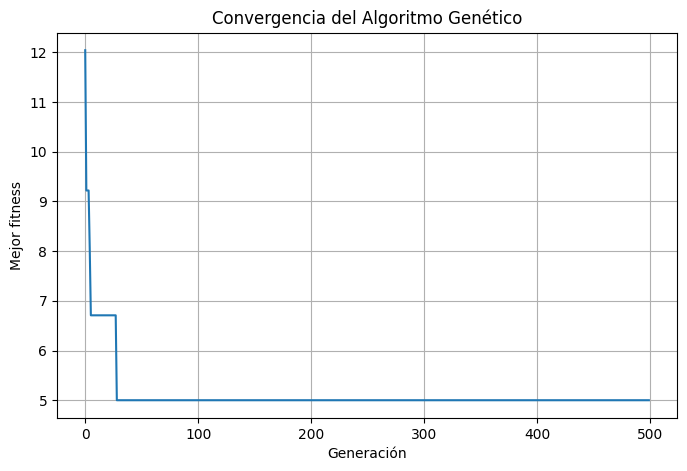

In [ ]:
# Grafica de convergencia.

plt.figure(figsize=(8,5))
plt.plot(historial)
plt.title("Convergencia del Algoritmo Genético")
plt.xlabel("Generación")
plt.ylabel("Mejor fitness")
plt.grid(True)
plt.show()

## Conclusiones

El problema de configuración de tribunales resultó ser más complejo de modelar de lo que parece a primera vista. La dificultad no está solo en el tamaño del espacio de búsqueda, sino en que las restricciones interactúan: un slot válido para un profesor puede dejar sin candidatos a otro rol, y eso obliga al algoritmo a buscar combinaciones que sean globalmente compatibles.

El Algoritmo Genético funcionó bien una vez que se ajustaron los pesos de penalización correctamente. Al principio, con pesos similares para restricciones duras y blandas, el algoritmo encontraba soluciones "equilibradas" que en realidad violaban disponibilidades. Subir el peso de las infracciones duras a 100–200 puntos fue lo que permitió que la factibilidad se impusiera antes que el equilibrio.

El resultado final cumple todas las restricciones duras y distribuye los 15 tribunales entre los 10 profesores con una variación de solo 1 tribunal entre el mínimo (4) y el máximo (5), que es prácticamente el óptimo teórico dado que 15×3/10 = 4.5.

Si tuviera que repetir el ejercicio, probaría con un AG multiobjetivo tipo NSGA-II para separar explícitamente los objetivos de factibilidad y equilibrio, en lugar de fusionarlos en una sola función de penalización con pesos fijos. Ajustar esos pesos a mano fue la parte más costosa del proceso.